UNSW-NB15: intrusion detection and label-poisoning study
This notebook answers Parts A and B of the coursework brief.
Question: Can a neural network separate malicious from normal traffic, and how
quickly does its attack recall collapse when an insider changes training labels?
The notebook deliberately keeps the official train/test split. The test labels are
never altered. That matters: a poisoned test set would measure a broken exam rather
than a broken intrusion detector.
Dataset source used in the brief:
https://research.unsw.edu.au/projects/unsw-nb15-dataset
Official UNSW download folder:
https://unsw-my.sharepoint.com/:f:/g/personal/z5025758_ad_unsw_edu_au/EnuQZZn3XuNBjgfcUu4DIVMBLCHyoLHqOswirpOQifr1ag?e=gKWkLS

In [2]:
#Imports
from pathlib import Path
import json
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.exceptions import ConvergenceWarning
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)

SEED = 42
rng = np.random.default_rng(SEED)

data_folder = Path.home() / "data_folder "
figure_folder = Path("figures")
result_folder = Path("results")
model_folder = Path("saved_models")

for folder in (data_folder, figure_folder, result_folder, model_folder):
    folder.mkdir(parents=True, exist_ok=True)

train_file = data_folder / "UNSW_NB15_training-set.csv"
test_file = data_folder / "UNSW_NB15_testing-set.csv"

official_download_folder = (
    "https://unsw-my.sharepoint.com/:f:/g/personal/"
    "z5025758_ad_unsw_edu_au/"
    "EnuQZZn3XuNBjgfcUu4DIVMBLCHyoLHqOswirpOQifr1ag?e=gKWkLS"
)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update(
    {
        "figure.figsize": (10, 6),
        "axes.titleweight": "bold",
        "axes.spines.top": False,
        "axes.spines.right": False,
        "savefig.dpi": 180,
        "savefig.bbox": "tight",
    }
)

In [3]:
if not train_file.exists() or not test_file.exists():
    raise FileNotFoundError(
        "The two required UNSW-NB15 CSV files were not found."
    )

print("The two official UNSW-NB15 files were found.")

The two official UNSW-NB15 files were found.


In [4]:
train_data = pd.read_csv(train_file)
test_data = pd.read_csv(test_file)

for frame in (train_data, test_data):
    frame.columns = frame.columns.str.strip().str.lower()
    if "attack_cat" in frame.columns:
        frame["attack_cat"] = (
            frame["attack_cat"].astype(str).str.strip().replace({"nan": "Normal"})
        )

print("Training shape:", train_data.shape)
print("Testing shape: ", test_data.shape)
display(train_data.head())

Training shape: (175341, 45)
Testing shape:  (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


1. Quiet data checks before modelling
These checks are intentionally printed. They provide evidence that the two files
have compatible columns and that the target really is binary.

In [6]:
data_check = pd.DataFrame(
    {
        "training": [
            len(train_data),
            train_data.duplicated().sum(),
            train_data.isna().sum().sum(),
            train_data["label"].nunique(),
        ],
        "testing": [
            len(test_data),
            test_data.duplicated().sum(),
            test_data.isna().sum().sum(),
            test_data["label"].nunique(),
        ],
    },
    index=["rows", "duplicate rows", "missing cells", "target classes"],
)
display(data_check)

missing_from_test = sorted(set(train_data.columns) - set(test_data.columns))
missing_from_train = sorted(set(test_data.columns) - set(train_data.columns))
print("Only in training:", missing_from_test)
print("Only in testing: ", missing_from_train)

if missing_from_test or missing_from_train:
    raise ValueError("The train and test columns do not match.")

if not set(train_data["label"].dropna().unique()).issubset({0, 1}):
    raise ValueError("This notebook expects label=0 for normal and label=1 for attack.")

,training,testing
rows,175341,82332
duplicate rows,0,0
missing cells,0,0
target classes,2,2


Only in training: []
Only in testing:  []


2. EDA that looks at behaviour, not just histograms
The first figure is a traffic fingerprint. Each cell is the median feature value
for an attack family after a robust transformation. It reveals which attack families
leave similar network traces without letting extreme byte counts dominate the colour.

,attack,flows,share_%
0,Normal,56000,31.937767
1,Generic,40000,22.812691
2,Exploits,33393,19.044605
3,Fuzzers,18184,10.370649
4,DoS,12264,6.994371
5,Reconnaissance,10491,5.983198
6,Analysis,2000,1.140635
7,Backdoor,1746,0.995774
8,Shellcode,1133,0.646169
9,Worms,130,0.074141


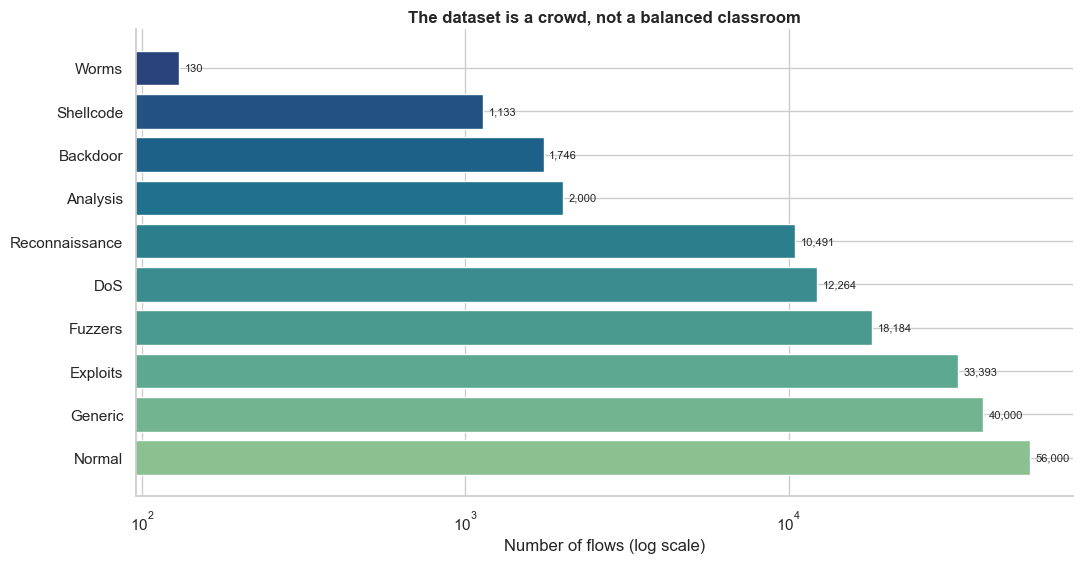

In [8]:
attack_order = (
    train_data["attack_cat"].value_counts().rename_axis("attack").reset_index(name="flows")
)
attack_order["share_%"] = 100 * attack_order["flows"] / len(train_data)
display(attack_order)

fig, ax = plt.subplots(figsize=(11, 5.8))
bars = ax.barh(
    attack_order["attack"],
    attack_order["flows"],
    color=sns.color_palette("crest", len(attack_order)),
)
ax.set_xscale("log")
ax.set_xlabel("Number of flows (log scale)")
ax.set_ylabel("")
ax.set_title("The dataset is a crowd, not a balanced classroom")
ax.bar_label(bars, labels=[f"{x:,}" for x in attack_order["flows"]], padding=4, fontsize=8)
plt.tight_layout()
plt.savefig(figure_folder / "01_attack_population_log_lollipop.png")
plt.show()

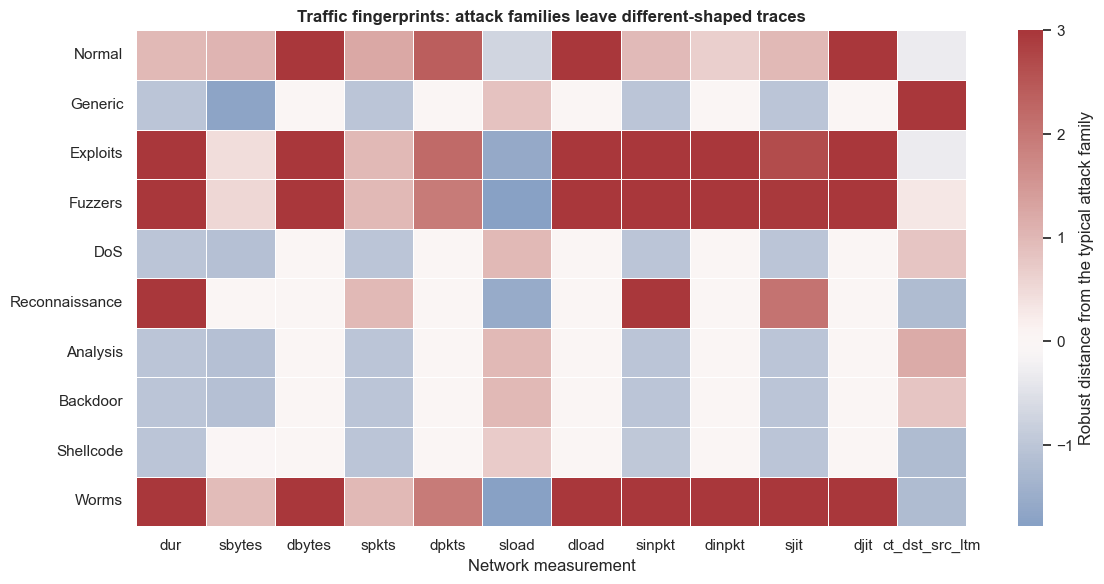

In [9]:
fingerprint_features = [
    name
    for name in [
        "dur",
        "sbytes",
        "dbytes",
        "spkts",
        "dpkts",
        "sload",
        "dload",
        "sinpkt",
        "dinpkt",
        "sjit",
        "djit",
        "ct_dst_src_ltm",
    ]
    if name in train_data.columns
]

fingerprint_source = train_data[["attack_cat", *fingerprint_features]].copy()
for column in fingerprint_features:
    # log1p softens very long tails; clipping also handles any unusual negative value.
    fingerprint_source[column] = np.log1p(
        fingerprint_source[column].clip(lower=0)
    )

median_by_attack = fingerprint_source.groupby("attack_cat")[fingerprint_features].median()
robust_centre = median_by_attack.median()
robust_spread = (median_by_attack - robust_centre).abs().median().replace(0, 1)
fingerprint = ((median_by_attack - robust_centre) / robust_spread).clip(-3, 3)
fingerprint = fingerprint.loc[attack_order["attack"]]

plt.figure(figsize=(12, 6))
sns.heatmap(
    fingerprint,
    cmap="vlag",
    center=0,
    linewidths=0.45,
    cbar_kws={"label": "Robust distance from the typical attack family"},
)
plt.title("Traffic fingerprints: attack families leave different-shaped traces")
plt.xlabel("Network measurement")
plt.ylabel("")
plt.tight_layout()
plt.savefig(figure_folder / "02_attack_traffic_fingerprints.png")
plt.show()

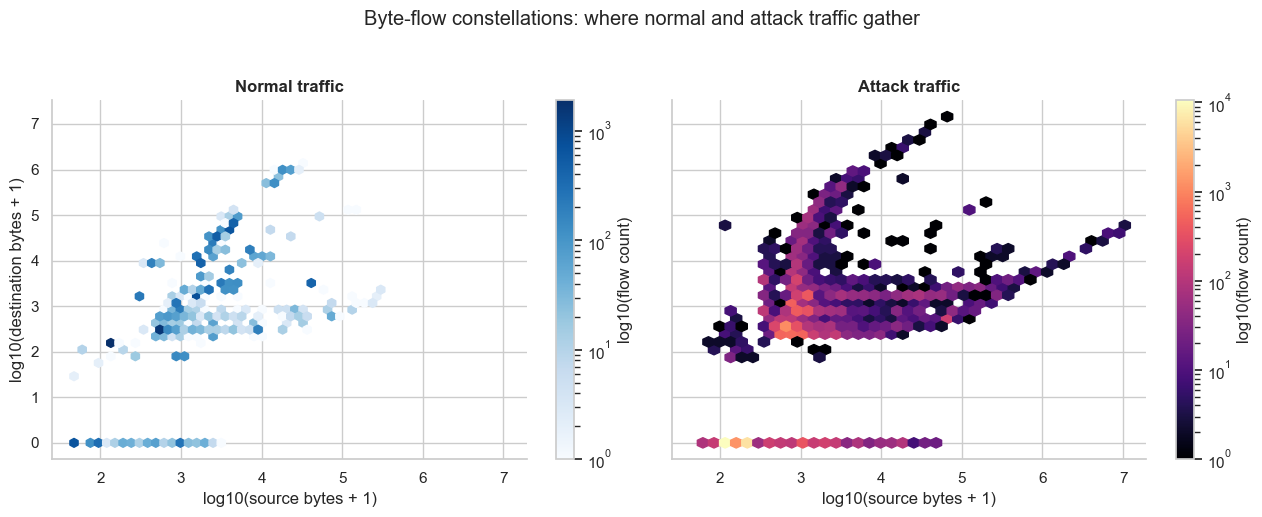

In [10]:
# A hexbin shows density.
plot_sample = train_data.sample(min(45_000, len(train_data)), random_state=SEED).copy()
x_name = "sbytes"
y_name = "dbytes"
plot_sample["log_source_bytes"] = np.log10(plot_sample[x_name].clip(lower=0) + 1)
plot_sample["log_destination_bytes"] = np.log10(plot_sample[y_name].clip(lower=0) + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for label_value, title, colour_map, ax in [
    (0, "Normal traffic", "Blues", axes[0]),
    (1, "Attack traffic", "magma", axes[1]),
]:
    piece = plot_sample[plot_sample["label"] == label_value]
    picture = ax.hexbin(
        piece["log_source_bytes"],
        piece["log_destination_bytes"],
        gridsize=38,
        bins="log",
        mincnt=1,
        cmap=colour_map,
    )
    ax.set_title(title)
    ax.set_xlabel("log10(source bytes + 1)")
    fig.colorbar(picture, ax=ax, label="log10(flow count)")
axes[0].set_ylabel("log10(destination bytes + 1)")
fig.suptitle("Byte-flow constellations: where normal and attack traffic gather", y=1.03)
plt.tight_layout()
plt.savefig(figure_folder / "03_byte_flow_constellations.png")
plt.show()

3. Preprocessing without information leakage
id is only a row identifier and attack_cat gives away the answer, so neither is
allowed into the model. Numerical values are median-filled and scaled. Text fields
are filled and one-hot encoded. Everything is fitted using training data only.

In [12]:
columns_not_used_as_predictors = ["label", "attack_cat", "id"]
feature_columns = [
    column for column in train_data.columns if column not in columns_not_used_as_predictors
]

X_train_full = train_data[feature_columns].copy()
y_train_full = train_data["label"].astype(int).copy()
X_test = test_data[feature_columns].copy()
y_test = test_data["label"].astype(int).copy()

category_columns = X_train_full.select_dtypes(include=["object", "category"]).columns.tolist()
number_columns = [c for c in feature_columns if c not in category_columns]

number_steps = Pipeline(
    [
        ("fill_missing", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]
)
category_steps = Pipeline(
    [
        ("fill_missing", SimpleImputer(strategy="most_frequent")),
        ("one_hot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preparation = ColumnTransformer(
    [
        ("numbers", number_steps, number_columns),
        ("categories", category_steps, category_columns),
    ]
)

# This validation slice is used for model choice.
X_build, X_validation, y_build, y_validation = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    stratify=y_train_full,
    random_state=SEED,
)

print(f"Numeric predictors: {len(number_columns)}")
print(f"Categorical predictors: {category_columns}")

Numeric predictors: 39
Categorical predictors: ['proto', 'service', 'state']


4. Part A - experiments that justify the model choice
A linear logistic model is the sanity-check baseline. Three neural networks then
test whether extra depth or width actually earns its cost. The selection score is
attack F1, not accuracy, because an intrusion detector must balance missed attacks
against false alarms.

In [14]:
candidate_models = {
    "Linear baseline": LogisticRegression(
        max_iter=300,
        class_weight="balanced",
        solver="liblinear",
        random_state=SEED,
    ),
    "Small MLP (32)": MLPClassifier(
        hidden_layer_sizes=(32,),
        activation="relu",
        alpha=0.0005,
        batch_size=512,
        learning_rate_init=0.001,
        early_stopping=True,
        validation_fraction=0.12,
        n_iter_no_change=8,
        max_iter=80,
        random_state=SEED,
    ),
    "Wide MLP (64, 32)": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        alpha=0.0005,
        batch_size=512,
        learning_rate_init=0.001,
        early_stopping=True,
        validation_fraction=0.12,
        n_iter_no_change=8,
        max_iter=80,
        random_state=SEED,
    ),
    "Regularised MLP (64, 32)": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        alpha=0.01,
        batch_size=512,
        learning_rate_init=0.001,
        early_stopping=True,
        validation_fraction=0.12,
        n_iter_no_change=8,
        max_iter=80,
        random_state=SEED,
    ),
}


def measure_binary_model(name, fitted_model, X, y, seconds):
    prediction = fitted_model.predict(X)
    probability = fitted_model.predict_proba(X)[:, 1]
    tn, fp, fn, tp = confusion_matrix(y, prediction, labels=[0, 1]).ravel()
    return {
        "model": name,
        "attack_precision": precision_score(y, prediction, zero_division=0),
        "attack_recall": recall_score(y, prediction, zero_division=0),
        "attack_f1": f1_score(y, prediction, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(y, prediction),
        "roc_auc": roc_auc_score(y, probability),
        "false_alarm_rate": fp / (fp + tn),
        "miss_rate": fn / (fn + tp),
        "fit_seconds": seconds,
    }


experiment_rows = []
fitted_candidates = {}

for model_name, model in candidate_models.items():
    print(f"Training: {model_name}")
    pipeline = Pipeline([("prepare", clone(preparation)), ("model", clone(model))])
    started = time.perf_counter()
    pipeline.fit(X_build, y_build)
    elapsed = time.perf_counter() - started
    experiment_rows.append(
        measure_binary_model(
            model_name, pipeline, X_validation, y_validation, elapsed
        )
    )
    fitted_candidates[model_name] = pipeline

model_experiments = (
    pd.DataFrame(experiment_rows).sort_values("attack_f1", ascending=False).reset_index(drop=True)
)
display(model_experiments.style.format(precision=4))
model_experiments.to_csv(result_folder / "model_choice_experiments.csv", index=False)

Training: Linear baseline
Training: Small MLP (32)
Training: Wide MLP (64, 32)
Training: Regularised MLP (64, 32)


,model,attack_precision,attack_recall,attack_f1,balanced_accuracy,roc_auc,false_alarm_rate,miss_rate,fit_seconds
0,"Wide MLP (64, 32)",0.9502,0.9739,0.9619,0.9325,0.9904,0.1088,0.0261,37.4688
1,Small MLP (32),0.9479,0.9742,0.9608,0.9300,0.9893,0.1142,0.0258,9.8404
2,"Regularised MLP (64, 32)",0.9485,0.9700,0.9591,0.9288,0.9884,0.1123,0.0300,8.3555
3,Linear baseline,0.9502,0.9509,0.9506,0.9223,0.9845,0.1062,0.0491,4.1949


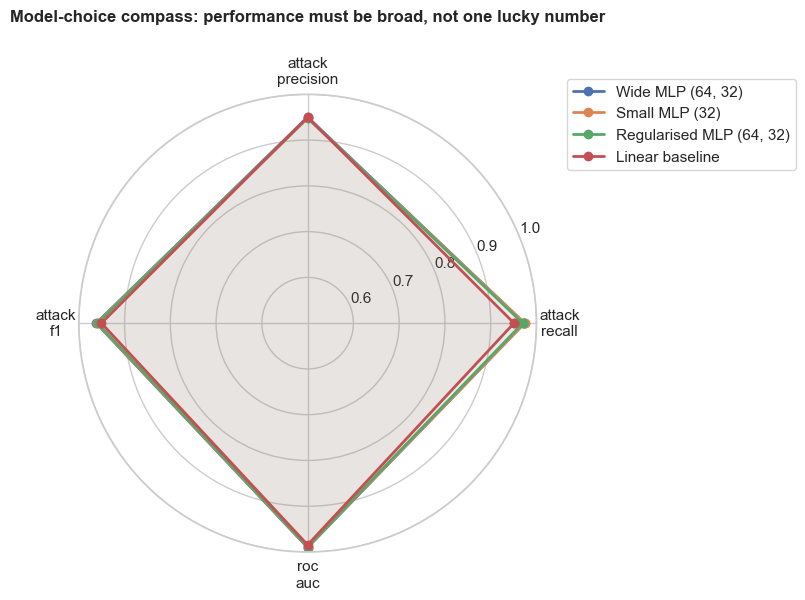

In [15]:
metrics_to_draw = ["attack_recall", "attack_precision", "attack_f1", "roc_auc"]
model_radar = model_experiments.set_index("model")[metrics_to_draw]
angles = np.linspace(0, 2 * np.pi, len(metrics_to_draw), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={"polar": True})
for model_name, row in model_radar.iterrows():
    values = row.tolist() + [row.iloc[0]]
    ax.plot(angles, values, linewidth=2, marker="o", label=model_name)
    ax.fill(angles, values, alpha=0.05)
ax.set_xticks(angles[:-1], [name.replace("_", "\n") for name in metrics_to_draw])
ax.set_ylim(0.5, 1.0)
ax.set_yticks([0.6, 0.7, 0.8, 0.9, 1.0])
ax.set_title("Model-choice compass: performance must be broad, not one lucky number", pad=25)
ax.legend(loc="upper left", bbox_to_anchor=(1.05, 1.05))
plt.tight_layout()
plt.savefig(figure_folder / "04_model_choice_compass.png")
plt.show()

Chosen neural network: Wide MLP (64, 32)


,model,attack_precision,attack_recall,attack_f1,balanced_accuracy,roc_auc,false_alarm_rate,miss_rate,fit_seconds
0,Clean training labels,0.8229,0.9781,0.8938,0.8601,0.9783,0.2578,0.0219,27.5912


              precision    recall  f1-score   support

      Normal       0.97      0.74      0.84     37000
      Attack       0.82      0.98      0.89     45332

    accuracy                           0.87     82332
   macro avg       0.89      0.86      0.87     82332
weighted avg       0.89      0.87      0.87     82332



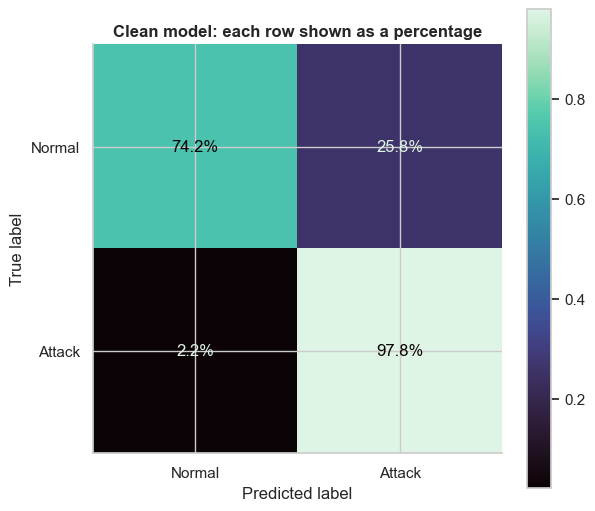

['saved_models/clean_intrusion_detector.joblib']

In [16]:
# Part B. this partasks for an intrusion detection neural network, so the best MLP is chosen among the neural candidates.
neural_results = model_experiments[model_experiments["model"].str.contains("MLP")]
chosen_name = neural_results.iloc[0]["model"]
chosen_estimator = candidate_models[chosen_name]
print("Chosen neural network:", chosen_name)

clean_model = Pipeline(
    [("prepare", clone(preparation)), ("model", clone(chosen_estimator))]
)
clean_start = time.perf_counter()
clean_model.fit(X_train_full, y_train_full)
clean_seconds = time.perf_counter() - clean_start

clean_result = measure_binary_model(
    "Clean training labels", clean_model, X_test, y_test, clean_seconds
)
display(pd.DataFrame([clean_result]).style.format(precision=4))

clean_prediction = clean_model.predict(X_test)
print(classification_report(y_test, clean_prediction, target_names=["Normal", "Attack"]))

fig, ax = plt.subplots(figsize=(6.3, 5.5))
ConfusionMatrixDisplay.from_predictions(
    y_test,
    clean_prediction,
    display_labels=["Normal", "Attack"],
    normalize="true",
    cmap="mako",
    values_format=".1%",
    ax=ax,
)
ax.set_title("Clean model: each row shown as a percentage")
plt.tight_layout()
plt.savefig(figure_folder / "05_clean_model_confusion_matrix.png")
plt.show()

joblib.dump(clean_model, model_folder / "clean_intrusion_detector.joblib")

Part B - insider label-poisoning experiment
Two attacks are compared at 0%, 5%, 10%, 15%, 20% and 25%.

1.Random label flipping: randomly chosen training labels are reversed. This is
the simple baseline mentioned in the brief.

2.Boundary attack-to-normal: only real attacks are changed to normal, starting
with malicious flows that the clean model already considers least convincing.
These samples sit close to the decision boundary, so a dishonest insider spends
the label budget where it is more likely to move that boundary. This is both
stealthier and more relevant than wasting flips on normal traffic.

The percentage is a share of all training rows. If the requested budget ever
exceeds the number of attack rows, it is safely capped.

In [18]:
poison_levels = [0, 5, 10, 15, 20, 25]


def random_flip_labels(clean_labels, percentage, random_seed):
    """Reverse a random percentage of all binary labels."""
    poisoned = clean_labels.copy()
    count = int(round(len(poisoned) * percentage / 100))
    local_rng = np.random.default_rng(random_seed)
    chosen = local_rng.choice(len(poisoned), size=count, replace=False)
    poisoned.iloc[chosen] = 1 - poisoned.iloc[chosen]
    return poisoned, chosen


# Score every training row once. No test information is used to choose poison points.
clean_train_attack_probability = clean_model.predict_proba(X_train_full)[:, 1]
attack_positions = np.flatnonzero(y_train_full.to_numpy() == 1)
attack_certainty = clean_train_attack_probability[attack_positions]


def boundary_attack_to_normal(clean_labels, percentage):
    """Hide low-margin attacks by changing their training label from 1 to 0."""
    poisoned = clean_labels.copy()
    requested = int(round(len(poisoned) * percentage / 100))
    count = min(requested, len(attack_positions))


    ranked_attack_positions = attack_positions[np.argsort(attack_certainty)]
    chosen = ranked_attack_positions[:count]
    poisoned.iloc[chosen] = 0
    return poisoned, chosen


def run_poison_experiment(strategy_name, poison_function, levels):
    rows = []
    trained_models = {}

    for level in levels:
        print(f"{strategy_name}: {level}%")
        poisoned_labels, changed_positions = poison_function(y_train_full, level)
        model = Pipeline(
            [("prepare", clone(preparation)), ("model", clone(chosen_estimator))]
        )
        started = time.perf_counter()
        model.fit(X_train_full, poisoned_labels)
        seconds = time.perf_counter() - started

        row = measure_binary_model(
            f"{strategy_name} - {level}%", model, X_test, y_test, seconds
        )
        row.update(
            {
                "strategy": strategy_name,
                "poison_%": level,
                "labels_changed": len(changed_positions),
                "actual_changed_%": 100 * len(changed_positions) / len(y_train_full),
            }
        )
        rows.append(row)
        trained_models[level] = model

    return pd.DataFrame(rows), trained_models


random_results, random_models = run_poison_experiment(
    "Random flip",
    lambda labels, level: random_flip_labels(labels, level, SEED + level),
    poison_levels,
)

targeted_results, targeted_models = run_poison_experiment(
    "Boundary attack-to-normal",
    boundary_attack_to_normal,
    poison_levels,
)

poison_results = pd.concat([random_results, targeted_results], ignore_index=True)
poison_results = poison_results[
    [
        "strategy",
        "poison_%",
        "labels_changed",
        "actual_changed_%",
        "attack_precision",
        "attack_recall",
        "attack_f1",
        "balanced_accuracy",
        "roc_auc",
        "false_alarm_rate",
        "miss_rate",
        "fit_seconds",
    ]
]
display(poison_results.style.format(precision=4))
poison_results.to_csv(result_folder / "poisoning_results.csv", index=False)

Random flip: 0%
Random flip: 5%
Random flip: 10%
Random flip: 15%
Random flip: 20%
Random flip: 25%
Boundary attack-to-normal: 0%
Boundary attack-to-normal: 5%
Boundary attack-to-normal: 10%
Boundary attack-to-normal: 15%
Boundary attack-to-normal: 20%
Boundary attack-to-normal: 25%


,strategy,poison_%,labels_changed,actual_changed_%,attack_precision,attack_recall,attack_f1,balanced_accuracy,roc_auc,false_alarm_rate,miss_rate,fit_seconds
0,Random flip,0,0,0.0000,0.8229,0.9781,0.8938,0.8601,0.9783,0.2578,0.0219,21.8078
1,Random flip,5,8767,5.0000,0.8031,0.9809,0.8832,0.8432,0.9735,0.2946,0.0191,27.8894
2,Random flip,10,17534,9.9999,0.8098,0.9772,0.8857,0.8480,0.9728,0.2812,0.0228,35.3751
3,Random flip,15,26301,14.9999,0.7811,0.9829,0.8704,0.8227,0.9656,0.3375,0.0171,12.2763
4,Random flip,20,35068,19.9999,0.7903,0.9867,0.8776,0.8329,0.9657,0.3208,0.0133,25.8224
5,Random flip,25,43835,24.9999,0.7877,0.9732,0.8707,0.8259,0.9614,0.3213,0.0268,17.7811
6,Boundary attack-to-normal,0,0,0.0000,0.8229,0.9781,0.8938,0.8601,0.9783,0.2578,0.0219,25.2324
7,Boundary attack-to-normal,5,8767,5.0000,0.8936,0.9355,0.9141,0.8995,0.9769,0.1364,0.0645,28.1793
8,Boundary attack-to-normal,10,17534,9.9999,0.9621,0.8685,0.9129,0.9133,0.9717,0.0419,0.1315,39.5738
9,Boundary attack-to-normal,15,26301,14.9999,0.9945,0.7878,0.8792,0.8912,0.9615,0.0053,0.2122,34.5551


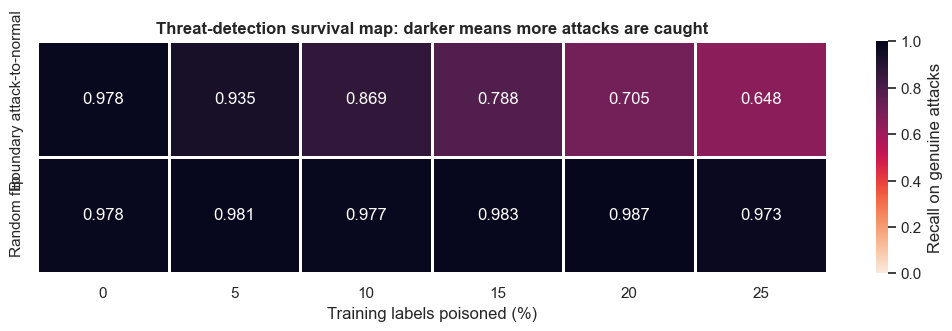

In [19]:
# A degradation map makes the direction and speed of damage visible at once.
heatmap_table = poison_results.pivot(
    index="strategy", columns="poison_%", values="attack_recall"
)
plt.figure(figsize=(10.5, 3.4))
sns.heatmap(
    heatmap_table,
    annot=True,
    fmt=".3f",
    cmap="rocket_r",
    vmin=0,
    vmax=1,
    linewidths=1,
    cbar_kws={"label": "Recall on genuine attacks"},
)
plt.title("Threat-detection survival map: darker means more attacks are caught")
plt.xlabel("Training labels poisoned (%)")
plt.ylabel("")
plt.tight_layout()
plt.savefig(figure_folder / "06_poisoning_survival_map.png")
plt.show()

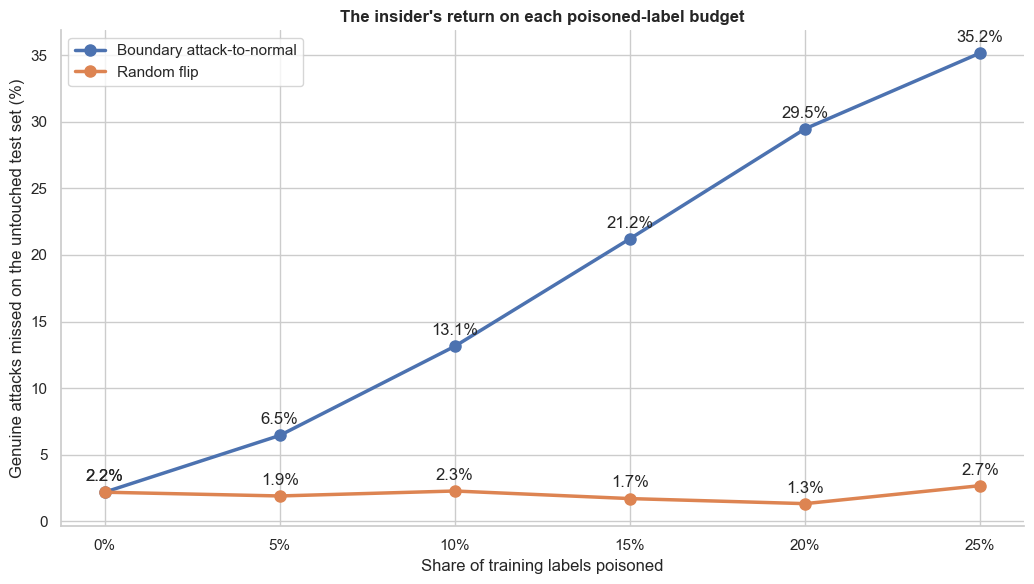

In [20]:
fig, ax = plt.subplots(figsize=(10.5, 6))
for strategy, piece in poison_results.groupby("strategy"):
    ax.plot(
        piece["poison_%"],
        100 * piece["miss_rate"],
        marker="o",
        markersize=8,
        linewidth=2.5,
        label=strategy,
    )
    for x, y in zip(piece["poison_%"], 100 * piece["miss_rate"]):
        ax.annotate(f"{y:.1f}%", (x, y), xytext=(0, 8), textcoords="offset points", ha="center")
ax.set_xlabel("Share of training labels poisoned")
ax.set_ylabel("Genuine attacks missed on the untouched test set (%)")
ax.set_title("The insider's return on each poisoned-label budget")
ax.set_xticks(poison_levels, [f"{x}%" for x in poison_levels])
ax.legend(frameon=True)
plt.tight_layout()
plt.savefig(figure_folder / "07_insider_return_curve.png")
plt.show()

6. Which attack families disappear first?
Overall recall can hide a serious weakness. The next figure calculates recall
separately for each named attack family under clean training and the strongest
targeted poisoning level.

,attack_family,test_flows,clean_recall,poisoned_recall,recall_lost
5,Generic,18871,0.9998,0.9730,0.0268
0,Analysis,677,0.9985,0.8597,0.1388
1,Backdoor,583,0.9966,0.8439,0.1527
2,DoS,4089,0.9932,0.7596,0.2336
3,Exploits,11132,0.9943,0.4755,0.5188
4,Fuzzers,6062,0.8562,0.1989,0.6572
8,Worms,44,1.0000,0.1364,0.8636
6,Reconnaissance,3496,0.9951,0.0990,0.8962
7,Shellcode,378,0.9841,0.0026,0.9815


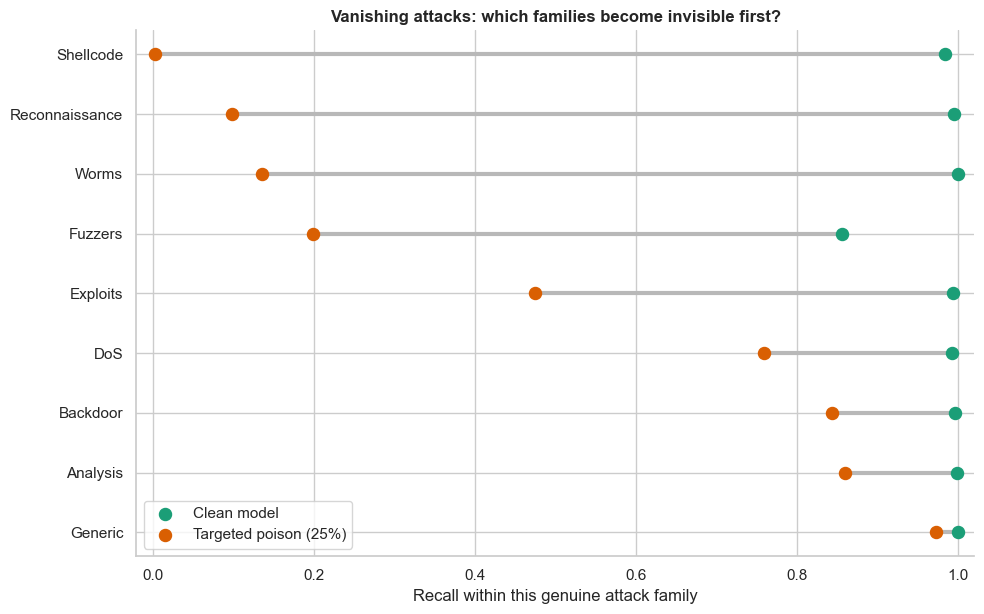

In [22]:
worst_level = max(poison_levels)
worst_targeted_model = targeted_models[worst_level]
worst_prediction = worst_targeted_model.predict(X_test)

family_rows = []
for family in sorted(test_data.loc[test_data["label"] == 1, "attack_cat"].unique()):
    family_mask = (test_data["attack_cat"] == family) & (y_test == 1)
    family_rows.append(
        {
            "attack_family": family,
            "test_flows": int(family_mask.sum()),
            "clean_recall": float(clean_prediction[family_mask].mean()),
            "poisoned_recall": float(worst_prediction[family_mask].mean()),
        }
    )

family_recall = pd.DataFrame(family_rows)
family_recall["recall_lost"] = family_recall["clean_recall"] - family_recall["poisoned_recall"]
family_recall = family_recall.sort_values("recall_lost", ascending=True)
display(family_recall.style.format(precision=4))
family_recall.to_csv(result_folder / "attack_family_recall.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 6.3))
for row in family_recall.itertuples():
    ax.plot(
        [row.poisoned_recall, row.clean_recall],
        [row.attack_family, row.attack_family],
        color="#b8b8b8",
        linewidth=3,
        zorder=1,
    )
ax.scatter(
    family_recall["clean_recall"],
    family_recall["attack_family"],
    s=75,
    color="#1b9e77",
    label="Clean model",
    zorder=2,
)
ax.scatter(
    family_recall["poisoned_recall"],
    family_recall["attack_family"],
    s=75,
    color="#d95f02",
    label=f"Targeted poison ({worst_level}%)",
    zorder=2,
)
ax.set_xlim(-0.02, 1.02)
ax.set_xlabel("Recall within this genuine attack family")
ax.set_ylabel("")
ax.set_title("Vanishing attacks: which families become invisible first?")
ax.legend()
plt.tight_layout()
plt.savefig(figure_folder / "08_attack_family_recall_dumbbell.png")
plt.show()

7. Experiment summary
The main experimental findings are also stored in a machine-readable JSON file.

In [33]:
clean_recall = poison_results.loc[
    (poison_results["strategy"] == "Boundary attack-to-normal")
    & (poison_results["poison_%"] == 0),
    "attack_recall",
].iloc[0]

worst_targeted_recall = poison_results.loc[
    (poison_results["strategy"] == "Boundary attack-to-normal")
    & (poison_results["poison_%"] == worst_level),
    "attack_recall",
].iloc[0]

summary = {
    "chosen_neural_network": chosen_name,
    "clean_test_attack_recall": round(float(clean_recall), 4),
    f"targeted_{worst_level}_percent_attack_recall": round(
        float(worst_targeted_recall), 4
    ),
    "absolute_recall_loss": round(float(clean_recall - worst_targeted_recall), 4),
    "most_harmed_attack_family": family_recall.iloc[-1]["attack_family"],
    "dataset_train_rows": int(len(train_data)),
    "dataset_test_rows": int(len(test_data)),
    "random_seed": SEED,
}

with (result_folder / "short_report_summary.json").open("w") as file:
    json.dump(summary, file, indent=2)

print(json.dumps(summary, indent=2))

{
  "chosen_neural_network": "Wide MLP (64, 32)",
  "clean_test_attack_recall": 0.9781,
  "targeted_25_percent_attack_recall": 0.6484,
  "absolute_recall_loss": 0.3297,
  "most_harmed_attack_family": "Shellcode",
  "dataset_train_rows": 175341,
  "dataset_test_rows": 82332,
  "random_seed": 42
}
